# Começando com Pyspark

Devido está mais familiarizado com Visual Studio Code, fiz adpatação para usar o spark dentro do meu VSCODE, para fins de estudos e treinamentos

In [1]:
# Importando Bibliotecas para uso do Spark para usar dentro do VSCODE
import findspark
findspark.init()
from pyspark.sql import SparkSession # Import para inciar o spark
from pyspark.sql.types import * # Todos as configurações do SQL de tipagem no spark
from pyspark.sql.functions import * # Todas as funções de SQL do Spark
# Criação da sessão Spark
spark = SparkSession.builder.appName("PySpark-VSCode-App").getOrCreate()
print("PySpark está pronto para uso!")

PySpark está pronto para uso!


**Criando um simples DataFrame Manualmente**

In [2]:
# Criando de forma manual os dados para tabela (DataFrame)
data = [("Jhon", 28), ("Anna", 24), ("Mike", 35)]
# Nome das colunas
Name_columns =  ["Nome", "Idade"]
# Comando spark para criação do Dataframe
df_Manual = spark.createDataFrame(data, schema=Name_columns)

**Adicionado uma coluna ao DataFrame**

In [3]:
df_Manual = df_Manual.withColumn("Idade_Apos_5_Anos", col('Idade') + 5 )

**Realizado a Leitura de um arquivo csv e definido as tipagem de cada coluna**

Antes de realizar a leitura do arquivo já posso definir como quero que cada coluna do arquivo seja lido e alterado seu tipo, assim facilitando transformação dos dados

In [4]:
# Definido o tipo de cada coluna
Schema_Sales = StructType([
    StructField('SalesOrderNumber', StringType()), # Tipo Texto
    StructField('SalesOrderLineNumber', IntegerType()), # Tipo Inteiro
    StructField('OrderDate', DateType()), # Tipo Data
    StructField('CustomerName', StringType()), 
    StructField('EmailAddress', StringType()), 
    StructField('Item', StringType()), 
    StructField('Quantity', IntegerType()), 
    StructField('UnitPrice', FloatType()), # Tipo Float
    StructField('TaxAmount', FloatType())
    ])

In [5]:
# Realizado o carregamento do arquivo csv
df = spark.read.load(r'G:\Meu Drive\Treinamentos\Fabric\Sales.csv', # Primeira variavel caminho onde localiza o arquivo
    format='csv',  # Formato / Extensão do arquivo
    schema=Schema_Sales, # Caso definido os nomes e as tipagens de cada coluna
    sep=',', # Delimitador do arquivo
    header=True, # Se a primeira coluna conter o nome das colunas
)

In [6]:
# Realizado a visualização dos 5 primeiros dados lidos utilizando sapark
display(df.limit(5).show())

+----------------+--------------------+----------+--------------+--------------------+--------------------+--------+---------+---------+
|SalesOrderNumber|SalesOrderLineNumber| OrderDate|  CustomerName|        EmailAddress|                Item|Quantity|UnitPrice|TaxAmount|
+----------------+--------------------+----------+--------------+--------------------+--------------------+--------+---------+---------+
|         SO43701|                   1|2019-07-01|   Christy Zhu|christy12@adventu...|Mountain-100 Silv...|       1|  3399.99| 271.9992|
|         SO43704|                   1|2019-07-01|    Julio Ruiz|julio1@adventure-...|Mountain-100 Blac...|       1|  3374.99| 269.9992|
|         SO43705|                   1|2019-07-01|     Curtis Lu|curtis9@adventure...|Mountain-100 Silv...|       1|  3399.99| 271.9992|
|         SO43700|                   1|2019-07-01|  Ruben Prasad|ruben10@adventure...|  Road-650 Black, 62|       1| 699.0982|  55.9279|
|         SO43703|                   1|20

None

In [ ]:
# Realizado a visualização dos 5 primeiros dados lidos utilizando a convesão para dataframe em pandas
df.toPandas().head()

,SalesOrderNumber,SalesOrderLineNumber,OrderDate,CustomerName,EmailAddress,Item,Quantity,UnitPrice,TaxAmount
0,SO43701,1,2019-07-01,Christy Zhu,christy12@adventure-works.com,"Mountain-100 Silver, 44",1,3399.989990,271.999207
1,SO43704,1,2019-07-01,Julio Ruiz,julio1@adventure-works.com,"Mountain-100 Black, 48",1,3374.989990,269.999207
2,SO43705,1,2019-07-01,Curtis Lu,curtis9@adventure-works.com,"Mountain-100 Silver, 38",1,3399.989990,271.999207
3,SO43700,1,2019-07-01,Ruben Prasad,ruben10@adventure-works.com,"Road-650 Black, 62",1,699.098206,55.927898
4,SO43703,1,2019-07-01,Albert Alvarez,albert7@adventure-works.com,"Road-150 Red, 62",1,3578.270020,286.261597


**Selecionado apenas algumas colunas**

Posso selecionar apenas colunas desejadas do meu DataFrame

In [8]:
selected_df = df.select("Item", "Quantity") # Selecionado apenas 2 coluna do meu Dataframe
selected_df.toPandas().head() # Visualizado os 5 primeiros registros

,Item,Quantity
0,"Mountain-100 Silver, 44",1
1,"Mountain-100 Black, 48",1
2,"Mountain-100 Silver, 38",1
3,"Road-650 Black, 62",1
4,"Road-150 Red, 62",1


**Realizado Filtros**

Posso filtro os meus dados usando o comando where e filtrar as informações de acordo com que eu desejar

In [ ]:
selected_filter_df = df.select("Item", "Quantity", "UnitPrice")\
.where((df["UnitPrice"]>1000)) # Realizando o filtro condicional, onde estou solicitado apenas os item com valores maiores que 1.000$

selected_filter_df.toPandas().head()

,Item,Quantity,UnitPrice
0,"Mountain-100 Silver, 44",1,3399.98999
1,"Mountain-100 Black, 48",1,3374.98999
2,"Mountain-100 Silver, 38",1,3399.98999
3,"Road-150 Red, 62",1,3578.27002
4,"Road-150 Red, 62",1,3578.27002


**Realizado agrupamentos**

Possível agrupar campos especificos e realizar calculos matemáticos, como Somas, Contagem, Médias, ...

In [13]:
# Realiza o agrupamento da informação Item, somando a coluna Quantity
selected_groupby_df = df.select("Item", "Quantity","UnitPrice")\
.groupby("Item").sum('Quantity')

selected_groupby_df.toPandas().head()

,Item,sum(Quantity)
0,"Mountain-200 Black, 42",388
1,"Touring-1000 Yellow, 46",74
2,"Touring-1000 Blue, 54",67
3,"Short-Sleeve Classic Jersey, S",216
4,"Women's Mountain Shorts, S",146


**Realizado ordenação das Colunas**

asc = Crescemte / 
desc = Decrescente

In [14]:
df_asc = selected_groupby_df.orderBy('sum(Quantity)') # Ordenação feita de forma crescente 
df_desc = selected_groupby_df.orderBy(desc('sum(Quantity)')) # Ordenação feita de forma decrescente

In [15]:
df_asc.toPandas().head()

,Item,sum(Quantity)
0,"Mountain-500 Black, 52",16
1,"Mountain-500 Silver, 40",16
2,"Mountain-500 Silver, 44",19
3,"Touring-3000 Yellow, 58",21
4,"Mountain-500 Silver, 42",22


In [16]:
df_desc.toPandas().head()

,Item,sum(Quantity)
0,Water Bottle - 30 oz.,2097
1,Patch Kit/8 Patches,1621
2,Mountain Tire Tube,1581
3,Road Tire Tube,1212
4,"Sport-100 Helmet, Red",1096


**Salvando arquivos em parquet**

Existe duas formas mais comuns de se armazenar o arquivo, em um arquivo unico, ou em um arquivo particionado usando como padrão os dados que contém em uma coluna especifica.

In [18]:
output = r'C:\tmp\hadoop-temp\Files\Sales.parquet'
df.write.mode("overwrite").parquet(output) # Salvado em um araquivo unico

In [17]:
output = r'C:\tmp\hadoop-temp\Files\Partitions\Sales.parquet'
df.write.partitionBy("Item").mode("overwrite").parquet(output) # Salvado particionado pela coluna Item

**Lendo arquivos Particionados especificos**

Ao reparticionar o arquivo em vários é possível fazer com que o fluxo leia apenas o arquivo selecionado ou desejado usando o comando Filter

In [ ]:
# 1. Lê o diretório raiz do Parquet
df_total = spark.read.parquet(output)
# 2. Filtra pelo item desejado. 
item_desejado = "All-Purpose Bike Stand"
# Usando o Comando filter do Spark para interar sobre os itens e abrir apenas o desejado
df_item_unico = df_total.filter(df_total["Item"] == item_desejado)
# Exibe o resultado
df_item_unico.toPandas().head()

,SalesOrderNumber,SalesOrderLineNumber,OrderDate,CustomerName,EmailAddress,Quantity,UnitPrice,TaxAmount,Item
0,SO51179,4,2021-05-31,Brad Chande,brad15@adventure-works.com,1,159.0,12.72,All-Purpose Bike Stand
1,SO51488,5,2021-06-19,Kate Tang,kate3@adventure-works.com,1,159.0,12.72,All-Purpose Bike Stand
2,SO51520,3,2021-06-21,Chloe Young,chloe23@adventure-works.com,1,159.0,12.72,All-Purpose Bike Stand
3,SO51558,4,2021-06-23,Isabelle Long,isabelle8@adventure-works.com,1,159.0,12.72,All-Purpose Bike Stand
4,SO51903,3,2021-07-01,Mandy Ma,mandy17@adventure-works.com,1,159.0,12.72,All-Purpose Bike Stand


**Realizado a criação de graficos com Pyspark**

Para realizar o uso do Matplotlib para criação de um gráfico é necessário realizar converter as informações em Pandas, e chamar o gráfico

<Figure size 640x480 with 0 Axes>

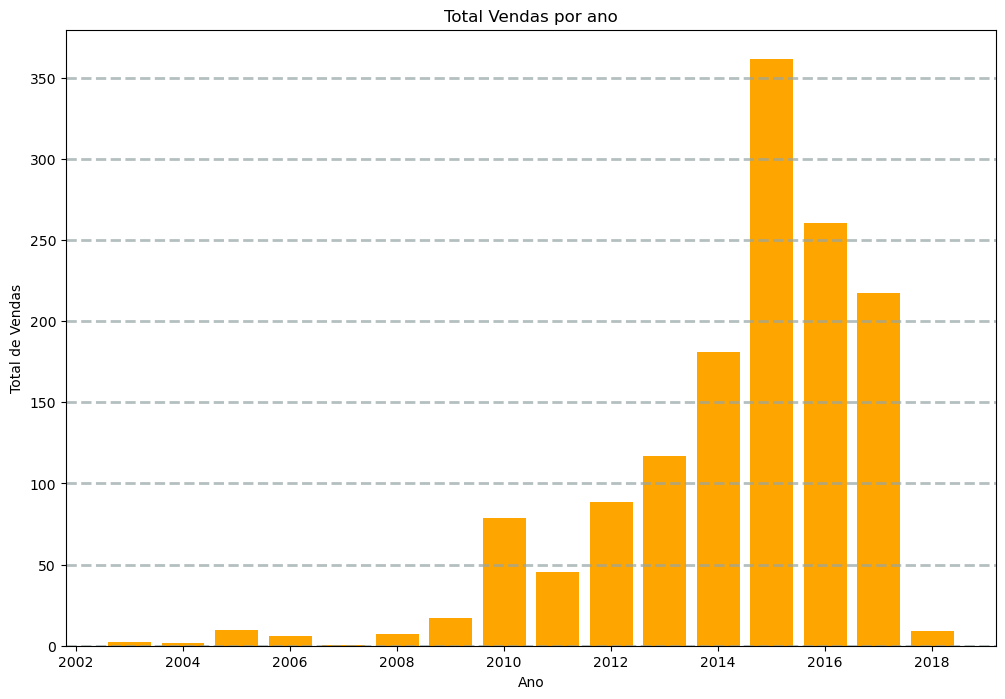

In [ ]:
from matplotlib import pyplot as plt # Importando biblioteca para criar gráfico

# Obtendo os dados para criação do gráfico
diretorio = r'G:\Meu Drive\Power BI - Yotube Documentos\00_DataSets\01_csv\car_data.csv'
data = spark.read\
    .format('csv')\
    .option('header', 'true')\
    .option('sep', ',')\
    .option('inferSchema', 'true')\
    .load(diretorio)
# Realizado o agrupamento e a conversão para pandas para ser aceito pelo matplotylib
data = data.groupby("ano").sum('preco_venda').toPandas()

# Limpando a área de plotagem
plt.clf()

# Criado a figura e definido o seu tamanho
fig = plt.figure(figsize=(12,8))

# Criando um gráfico de barras definido como eixo X o Ano e o tamanho da barra a soma de preço de venda, e definido a cor laranja para barra
plt.bar(x=data['ano'], height=data['sum(preco_venda)'], color='orange')

# Customizado o gráfico
plt.title('Total Vendas por ano') # Adicionando um titulo
plt.xlabel('Ano') # Definido um titulo para o eixo X
plt.ylabel('Total de Vendas') # Definido um titulo para o eixo y 
plt.grid(color='#95a5a6', linestyle='--', linewidth=2, axis='y', alpha=0.7) # Criado padronização para linhas de grades no eixo Y
plt.xticks(rotation=360) # definido a rotação dos nomes do eixo X

# Chamando o plot criado para visualização
plt.show()